# 01 — Mise en forme des données (MovieLens-20M → séquences pour JEPA)

Ce notebook déroule **pas à pas** la préparation des données, en appelant les fonctions du module `src/data_prep.py`. But : transformer 20M de notes brutes en **trajectoires de consommateurs** exploitables par une architecture JEPA.

## Rappel des décisions

| Décision | Choix | Pourquoi |
|---|---|---|
| Signal | Toutes les interactions (implicite) | Exploite tout le dataset ; note + timestamp gardés en réserve |
| Ordre | Chronologique à plat, écarts ignorés (v1) | Standard seq-rec, simple et explicable |
| Filtrage | Films couverts par le genome, puis **5-core** | Features de contenu propres, retire le bruit rare |
| Item | ID (embedding appris) **+ genome** (1128 tags) | Représentation riche et interprétable |
| Cap longueur | **500** derniers films | Garde 86 % du signal, tronque 5 % des users |
| Split | **Leave-one-out** (dernier=test, avant-dernier=val) | Standard, pas de fuite intra-user |

> ⚠️ Rappel important : les timestamps MovieLens sont des dates de **notation**, pas de visionnage — les gens notent en rafales. On l'assume en v1 (ordre chronologique à plat).

In [1]:
import sys
from pathlib import Path

# Rendre le package src importable depuis notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import src.data_prep as dp

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
print("Module chargé. Racine projet :", ROOT)

Module chargé. Racine projet : /Users/julesvidegrain/Desktop/Projets GitHub/Customer behavior


## Étape 1 — Charger les notes brutes

On lit `rating.csv` (~690 Mo, 20M lignes). Le timestamp est converti en **secondes unix** (int) — on n'a besoin que de l'ordre, pas de l'horodatage précis.

In [2]:
df = dp.load_ratings()
print(f"{len(df):,} interactions | {df['userId'].nunique():,} users | {df['movieId'].nunique():,} films")
df.head()

20,000,263 interactions | 138,493 users | 26,744 films


,userId,movieId,rating,timestamp
0,1,2,3.5,1112486
1,1,29,3.5,1112484
2,1,32,3.5,1112484
3,1,47,3.5,1112484
4,1,50,3.5,1112484


## Étape 2 — Ne garder que les films couverts par le genome

On a choisi *ID + genome* comme représentation d'item. Les films sans vecteur genome sont donc écartés. Rappel : ils ne pèsent que **0,9 %** des interactions (films rares).

In [3]:
genome_ids = dp.genome_movie_ids()
before = len(df)
df = dp.filter_to_genome(df, genome_ids)
print(f"Avant : {before:,} interactions")
print(f"Après : {len(df):,} interactions ({len(df)/before*100:.1f} %) | {df['movieId'].nunique():,} films")

Avant : 20,000,263 interactions
Après : 19,800,443 interactions (99.0 %) | 10,370 films


## Étape 3 — Filtrage 5-core

On ne garde que les users **et** les films ayant au moins 5 interactions, **itérativement** (retirer des films peut faire passer un user sous le seuil). MovieLens-20M étant déjà pré-filtré (≥ 20 notes/user), cette étape ne retire ici que quelques films devenus rares après l'étape 2.

In [4]:
before = len(df)
df = dp.k_core(df, dp.MIN_CORE)
print(f"Avant : {before:,} interactions")
print(f"Après : {len(df):,} interactions | {df['userId'].nunique():,} users | {df['movieId'].nunique():,} films")

Avant : 19,800,443 interactions
Après : 19,800,386 interactions | 138,493 users | 10,345 films


## Étape 4 — Tables d'indexation (id maps)

On mappe les `movieId` (épars) vers des **index internes contigus** `1..n_items`. **L'index 0 est réservé au padding** (aucun film réel), ce qui simplifiera le batching côté modèle. On garde aussi les titres pour l'interprétabilité.

In [5]:
maps = dp.build_id_maps(df)
print(f"{maps.n_users:,} users | {maps.n_items:,} films (index 1..{maps.n_items}, 0 = padding)")

# Exemple de mapping
sample_movie = list(maps.movie2idx.items())[:3]
for mid, idx in sample_movie:
    print(f"  movieId {mid} -> index {idx} -> {maps.titles[idx]}")

138,493 users | 10,345 films (index 1..10345, 0 = padding)
  movieId 1 -> index 1 -> Toy Story (1995)
  movieId 2 -> index 2 -> Jumanji (1995)
  movieId 3 -> index 3 -> Grumpier Old Men (1995)


## Étape 5 — Construire les séquences (trajectoires)

Pour chaque user : ses films **ordonnés par timestamp**, tronqués aux **500 derniers** (on garde les plus récents). On conserve aussi `ratings` et `timestamps` **en réserve** (non utilisés en v1) pour ne pas avoir à retraiter le fichier de 690 Mo plus tard.

In [6]:
sequences = dp.build_sequences(df, maps, dp.MAX_SEQ_LEN)
print(f"{len(sequences):,} séquences")
sequences[["userId", "length"]].describe().T

138,493 séquences


,count,mean,std,min,25%,50%,75%,max
userId,138493.0,69247.000000,39979.629753,1.0,34624.0,69247.0,103870.0,138493.0
length,138493.0,123.488646,131.494507,13.0,34.0,67.0,154.0,500.0


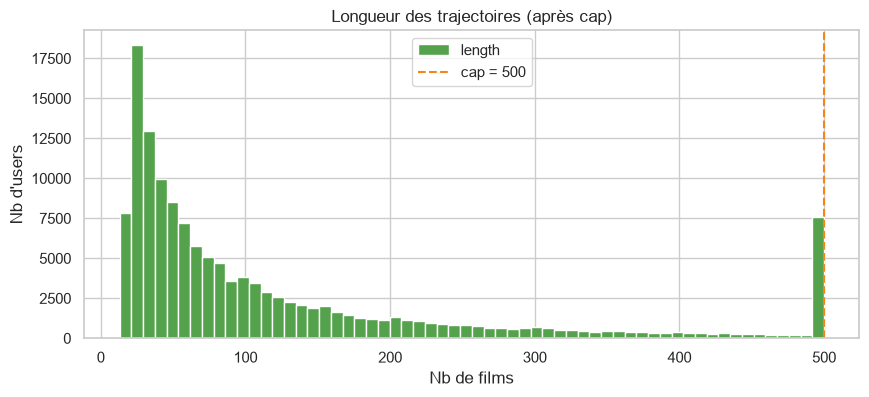

In [7]:
# Distribution des longueurs après cap
ax = sequences["length"].plot(kind="hist", bins=60, color="#54A24B")
ax.axvline(dp.MAX_SEQ_LEN, color="#F58518", ls="--", label=f"cap = {dp.MAX_SEQ_LEN}")
ax.set(title="Longueur des trajectoires (après cap)", xlabel="Nb de films", ylabel="Nb d'users")
ax.legend(); plt.show()

In [8]:
# Aperçu d'une trajectoire réelle (5 derniers films d'un user)
row = sequences.iloc[0]
print(f"User {row.userId} — {row.length} films. Les 5 derniers vus :")
for idx in row["items"][-5:]:
    print("   ", maps.titles[idx])

User 1 — 174 films. Les 5 derniers vus :
    Heavy Metal 2000 (2000)
    Scary Movie 3 (2003)
    One Million Years B.C. (1966)
    Godsend (2004)
    Van Helsing (2004)


## Étape 6 — Matrice genome (features de contenu)

Matrice `[n_items+1, 1128]` : chaque ligne = le vecteur de **pertinence [0,1]** du film sur les 1128 tags du genome. La ligne 0 (padding) est nulle. C'est la représentation de contenu qui rendra l'espace latent JEPA **interprétable**.

In [9]:
n_tags = dp.load_genome_tag_count()
genome = dp.build_genome_matrix(maps, n_tags)
print("genome:", genome.shape, "| ligne 0 (pad) nulle ?", bool((genome[0] == 0).all()))

genome: (10346, 1128) | ligne 0 (pad) nulle ? True


In [10]:
# Interprétabilité : les tags genome les plus pertinents pour un film donné
tag_names = pd.read_csv(dp.DATA / "genome_tags.csv").set_index("tagId")["tag"]

def top_genome_tags(item_idx, k=12):
    vec = genome[item_idx]
    top = np.argsort(vec)[::-1][:k]           # colonnes = tagId-1
    return pd.DataFrame({
        "tag": [tag_names[c + 1] for c in top],
        "relevance": vec[top].round(3),
    })

# Cherchons Toy Story dans le vocabulaire
toy = next((idx for idx, t in maps.titles.items() if t.startswith("Toy Story (")), 1)
print("Tags genome dominants pour :", maps.titles[toy])
top_genome_tags(toy)

Tags genome dominants pour : Toy Story (1995)


,tag,relevance
0,toys,0.999
1,computer animation,0.998
2,pixar animation,0.996
3,kids and family,0.991
4,animation,0.986
5,kids,0.979
6,pixar,0.967
7,children,0.964
8,cartoon,0.956
9,imdb top 250,0.942


## Étape 7 — Split leave-one-out

Pour chaque user : **dernier** film = test, **avant-dernier** = validation, **tout le reste** = contexte d'entraînement. Le split est *dérivé* à la volée (pas stocké), via `dp.leave_one_out`. Aucune fuite intra-user : le contexte ne contient que des films **antérieurs** à la cible.

In [11]:
ctx, val_target, test_target = dp.leave_one_out(row["items"])
print(f"User {row.userId} :")
print(f"  contexte train : {len(ctx)} films (les 3 derniers : {[maps.titles[i] for i in ctx[-3:]]})")
print(f"  cible VAL      : {maps.titles[val_target]}")
print(f"  cible TEST     : {maps.titles[test_target]}")

User 1 :
  contexte train : 172 films (les 3 derniers : ['Heavy Metal 2000 (2000)', 'Scary Movie 3 (2003)', 'One Million Years B.C. (1966)'])
  cible VAL      : Godsend (2004)
  cible TEST     : Van Helsing (2004)


## Étape 8 — Sauvegarde des artefacts

On écrit dans `data/processed/` :
- `sequences.parquet` — une ligne par user (items, ratings, timestamps, length)
- `genome.npy` — matrice de contenu `[n_items+1, 1128]`
- `id_maps.pkl` — tables d'indexation + titres

> Ces trois fichiers suffisent pour l'entraînement : **on ne relira plus jamais** le CSV de 690 Mo.

In [12]:
dp.save_all(sequences, genome, maps)
print("Artefacts écrits dans", dp.PROCESSED)
for p in sorted(dp.PROCESSED.glob("*")):
    print(f"  {p.name:20s} {p.stat().st_size/1e6:7.1f} Mo")

Artefacts écrits dans /Users/julesvidegrain/Desktop/Projets GitHub/Customer behavior/data/processed
  genome.npy              46.7 Mo
  id_maps.pkl              1.6 Mo
  sequences.parquet       54.7 Mo


In [13]:
# Contrôle final : on recharge et on vérifie la cohérence
seqs2, genome2, maps2 = dp.load_all()
assert seqs2.shape == sequences.shape
assert genome2.shape == genome.shape
assert maps2.n_items == maps.n_items and maps2.n_users == maps.n_users
print("Rechargement OK — la mise en forme est terminée.")
print(f"{maps2.n_users:,} trajectoires | {maps2.n_items:,} films | genome {genome2.shape}")

Rechargement OK — la mise en forme est terminée.
138,493 trajectoires | 10,345 films | genome (10346, 1128)


---
## Prochaine étape

Les données sont prêtes. La suite (à cadrer ensemble) : concevoir l'**architecture JEPA** — encodeur de contexte, prédicteur dans l'espace latent, cible construite à partir du genome + embedding d'ID, et la stratégie d'entraînement (masquage, negative sampling, loss). On en discutera pas à pas.